In [2]:
import warnings
warnings.filterwarnings('ignore')


In [3]:
!pip install openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl 

In [5]:
df = pd.read_excel(
    r"C:\Users\spars\OneDrive\Desktop\ML hcl training\Disease_Prediction_Health_Dataset.xlsx"
)


In [6]:
df.head()

,Age,Gender,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm,Smoking,Exercise_Level,Disease
0,56,Male,26.6,140,277,75,55,No,Moderate,Disease
1,69,Male,29.8,165,215,115,61,No,Low,No Disease
2,46,Male,24.1,128,189,77,50,No,Low,No Disease
3,32,Male,31.8,101,185,120,90,No,Moderate,No Disease
4,60,Male,27.0,170,201,122,76,Yes,Moderate,Disease


In [7]:
df.tail()


,Age,Gender,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm,Smoking,Exercise_Level,Disease
2995,68,Female,32.6,165,227,77,76,No,Low,No Disease
2996,32,Male,25.4,126,159,140,78,No,Moderate,No Disease
2997,21,Male,28.9,112,176,108,67,No,Low,No Disease
2998,38,Female,32.6,110,223,100,72,No,High,No Disease
2999,30,Female,24.6,125,179,127,60,Yes,High,No Disease


In [8]:
df.shape

(3000, 10)

In [9]:
df.columns

Index(['Age', 'Gender', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL',
       'Glucose_mg_dL', 'Heart_Rate_bpm', 'Smoking', 'Exercise_Level',
       'Disease'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  3000 non-null   int64  
 1   Gender               3000 non-null   str    
 2   BMI                  3000 non-null   float64
 3   Blood_Pressure_mmHg  3000 non-null   int64  
 4   Cholesterol_mg_dL    3000 non-null   int64  
 5   Glucose_mg_dL        3000 non-null   int64  
 6   Heart_Rate_bpm       3000 non-null   int64  
 7   Smoking              3000 non-null   str    
 8   Exercise_Level       3000 non-null   str    
 9   Disease              3000 non-null   str    
dtypes: float64(1), int64(5), str(4)
memory usage: 298.9 KB


In [11]:
df.describe()

,Age,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000
mean,49.446667,25.363333,132.236333,204.623000,108.447667,72.62600
std,18.207572,4.676400,19.317493,32.902245,24.384492,9.92201
min,18.000000,16.000000,90.000000,120.000000,65.000000,50.00000
25%,34.000000,22.100000,118.000000,182.000000,91.000000,66.00000
50%,50.000000,25.350000,132.000000,205.000000,108.500000,73.00000
75%,65.000000,28.600000,146.000000,227.000000,125.000000,79.00000
max,80.000000,41.100000,180.000000,311.000000,194.000000,118.00000


In [12]:
df.dtypes

Age                      int64
Gender                     str
BMI                    float64
Blood_Pressure_mmHg      int64
Cholesterol_mg_dL        int64
Glucose_mg_dL            int64
Heart_Rate_bpm           int64
Smoking                    str
Exercise_Level             str
Disease                    str
dtype: object

In [13]:
df.isnull().sum()

Age                    0
Gender                 0
BMI                    0
Blood_Pressure_mmHg    0
Cholesterol_mg_dL      0
Glucose_mg_dL          0
Heart_Rate_bpm         0
Smoking                0
Exercise_Level         0
Disease                0
dtype: int64

In [14]:
(df.isnull().sum()/len(df))*100

Age                    0.0
Gender                 0.0
BMI                    0.0
Blood_Pressure_mmHg    0.0
Cholesterol_mg_dL      0.0
Glucose_mg_dL          0.0
Heart_Rate_bpm         0.0
Smoking                0.0
Exercise_Level         0.0
Disease                0.0
dtype: float64

In [15]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDataset shape:")
print(df.shape)

Missing values:
Age                    0
Gender                 0
BMI                    0
Blood_Pressure_mmHg    0
Cholesterol_mg_dL      0
Glucose_mg_dL          0
Heart_Rate_bpm         0
Smoking                0
Exercise_Level         0
Disease                0
dtype: int64

Duplicate rows:
0

Dataset shape:
(3000, 10)


In [16]:
df[df.duplicated()]

,Age,Gender,BMI,Blood_Pressure_mmHg,Cholesterol_mg_dL,Glucose_mg_dL,Heart_Rate_bpm,Smoking,Exercise_Level,Disease


In [17]:
df = df.drop_duplicates()

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df['Disease'].value_counts()a

Disease
No Disease    2298
Disease        702
Name: count, dtype: int64

In [20]:
df['Disease'].value_counts(normalize=True) * 100

Disease
No Disease    76.6
Disease       23.4
Name: proportion, dtype: float64

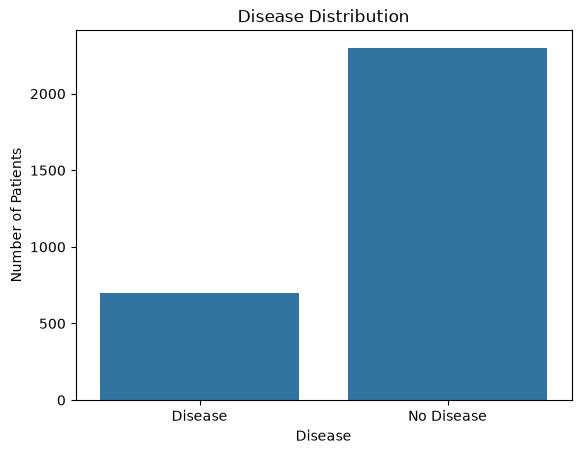

In [21]:
sns.countplot(x='Disease', data=df)

plt.title('Disease Distribution')
plt.xlabel('Disease')
plt.ylabel('Number of Patients')
plt.show()

In [22]:
print(df['Gender'].value_counts())
print(df['Smoking'].value_counts())
print(df['Exercise_Level'].value_counts())

Gender
Male      1573
Female    1427
Name: count, dtype: int64
Smoking
No     2169
Yes     831
Name: count, dtype: int64
Exercise_Level
Moderate    1359
Low         1091
High         550
Name: count, dtype: int64


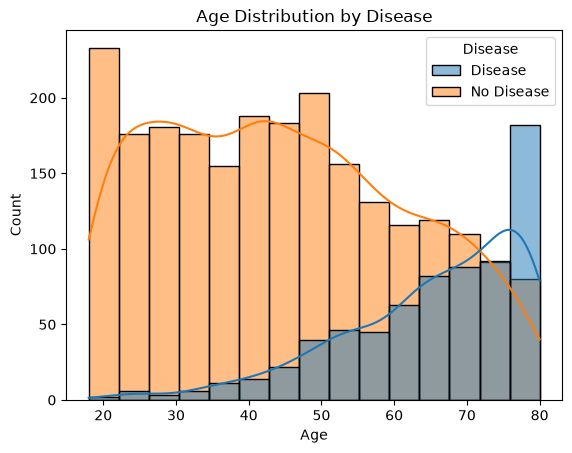

In [23]:
sns.histplot(data=df, x='Age', hue='Disease', kde=True)

plt.title('Age Distribution by Disease')
plt.show()

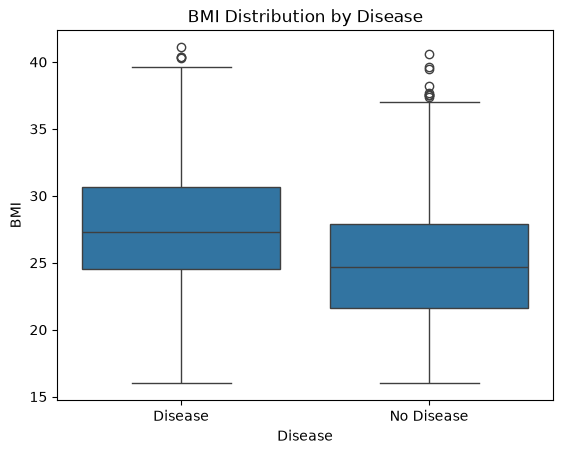

In [24]:
sns.boxplot(data=df, x='Disease', y='BMI')

plt.title('BMI Distribution by Disease')
plt.show()

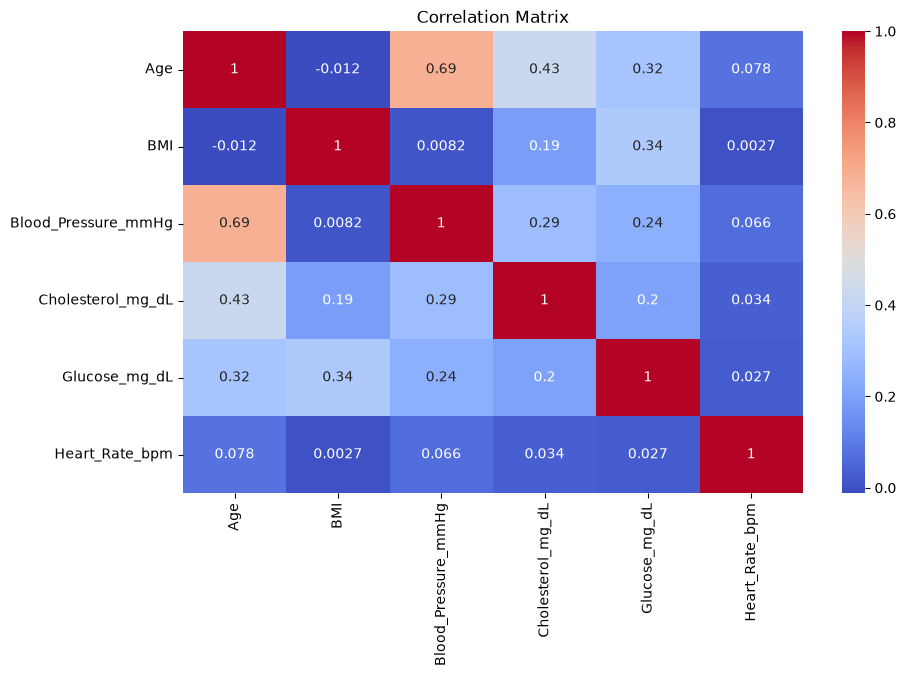

In [25]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include='number').corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')
plt.show()

In [26]:
X = df.drop('Disease', axis=1)
y = df['Disease']

In [27]:
print(X.shape)
print(y.shape)

(3000, 9)
(3000,)


In [28]:
print(X.shape)
print(y.shape)

(3000, 9)
(3000,)


In [29]:
numeric_features = [
    'Age',
    'BMI',
    'Blood_Pressure_mmHg',
    'Cholesterol_mg_dL',
    'Glucose_mg_dL',
    'Heart_Rate_bpm'
]

categorical_features = [
    'Gender',
    'Smoking',
    'Exercise_Level'
]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [33]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Disease','No Disease']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Age','Gender','BMI',...,'Heart_Rate_bpm','Smoking','Exercise_Level']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder

In [34]:
y_pred = logistic_model.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8583333333333333


In [36]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[ 83  57]
 [ 28 432]]

Classification Report:
              precision    recall  f1-score   support

     Disease       0.75      0.59      0.66       140
  No Disease       0.88      0.94      0.91       460

    accuracy                           0.86       600
   macro avg       0.82      0.77      0.79       600
weighted avg       0.85      0.86      0.85       600



<Figure size 600x500 with 0 Axes>

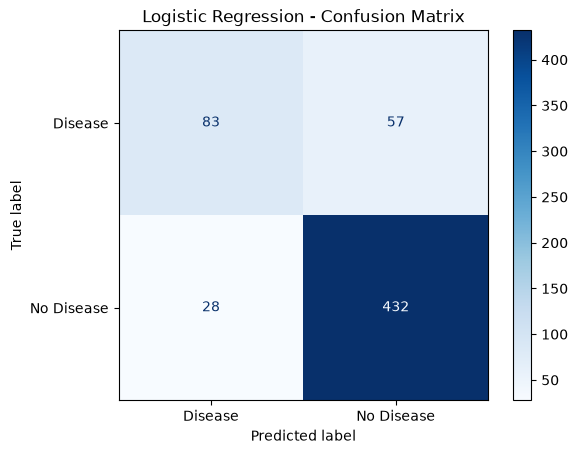

In [37]:
plt.figure(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [38]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', DecisionTreeClassifier(
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.815


In [39]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:
              precision    recall  f1-score   support

     Disease       0.61      0.59      0.60       140
  No Disease       0.88      0.88      0.88       460

    accuracy                           0.81       600
   macro avg       0.74      0.74      0.74       600
weighted avg       0.81      0.81      0.81       600



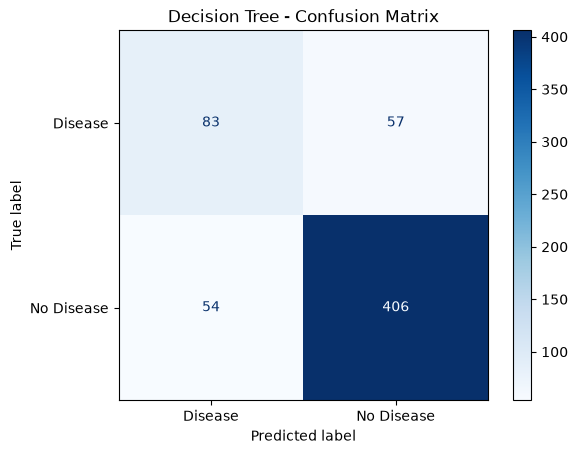

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    cmap='Blues'
)

plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [41]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.8533333333333334


In [42]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

     Disease       0.77      0.54      0.63       140
  No Disease       0.87      0.95      0.91       460

    accuracy                           0.85       600
   macro avg       0.82      0.74      0.77       600
weighted avg       0.85      0.85      0.84       600



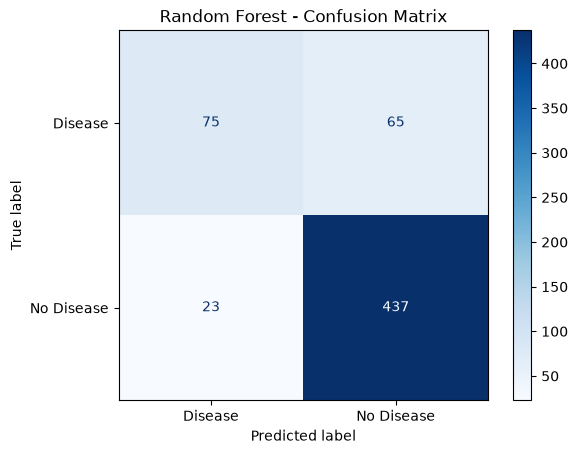

In [43]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap='Blues'
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [44]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.8066666666666666


In [45]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', SVC())
])

svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.8583333333333333


In [46]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM'
    ],
    'Accuracy': [
        accuracy,
        accuracy_dt,
        accuracy_rf,
        accuracy_knn,
        accuracy_svm
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.858333
1,Decision Tree,0.815000
2,Random Forest,0.853333
3,KNN,0.806667
4,SVM,0.858333


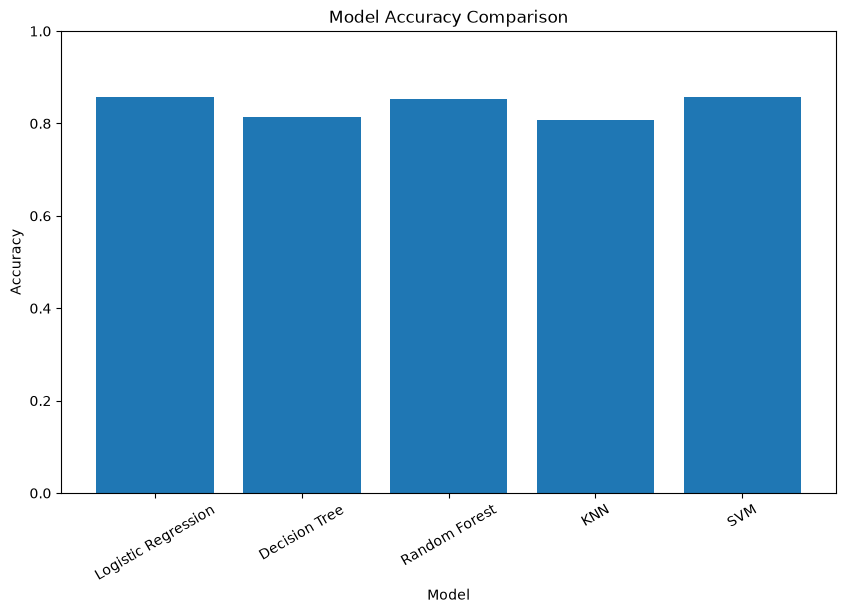

In [47]:
plt.figure(figsize=(10, 6))

plt.bar(
    model_results['Model'],
    model_results['Accuracy']
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")

plt.xticks(rotation=30)
plt.ylim(0, 1)

plt.show()

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": (logistic_model, y_pred),
    "Decision Tree": (decision_tree_model, y_pred_dt),
    "Random Forest": (random_forest_model, y_pred_rf),
    "KNN": (knn_model, y_pred_knn),
    "SVM": (svm_model, y_pred_svm)
}

for name, (model, predictions) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            pos_label="Disease"
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            pos_label="Disease"
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            pos_label="Disease"
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.858333,0.747748,0.592857,0.661355
1,Decision Tree,0.815000,0.605839,0.592857,0.599278
2,Random Forest,0.853333,0.765306,0.535714,0.630252
3,KNN,0.806667,0.617647,0.450000,0.520661
4,SVM,0.858333,0.795699,0.528571,0.635193


In [49]:
print(logistic_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'BMI',
                                                   'Blood_Pressure_mmHg',
                                                   'Cholesterol_mg_dL',
                                                   'Glucose_mg_dL',
                                                   'Heart_Rate_bpm']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'Smoking',
                                                   'Exercise_Level'])])),
                ('classifier', LogisticRegression(max_iter=1000))])


In [118]:
new_patient = pd.DataFrame({
    'Age': [89],
    'Gender': ['Male'],
    'BMI': [27.5],
    'Blood_Pressure_mmHg': [125],
    'Cholesterol_mg_dL': [210],
    'Glucose_mg_dL': [110],
    'Heart_Rate_bpm': [79],
    'Smoking': ['no'],
    'Exercise_Level': ['Moderate']
})

In [119]:
print(X.columns.tolist())

['Age', 'Gender', 'BMI', 'Blood_Pressure_mmHg', 'Cholesterol_mg_dL', 'Glucose_mg_dL', 'Heart_Rate_bpm', 'Smoking', 'Exercise_Level']


In [120]:
age = new_patient["Age"].iloc[0]
bmi = new_patient["BMI"].iloc[0]
blood_pressure = new_patient["Blood_Pressure_mmHg"].iloc[0]
glucose = new_patient["Glucose_mg_dL"].iloc[0]
heart_rate = new_patient["Heart_Rate_bpm"].iloc[0]

if (
    1 <= age <= 120
    and 10 <= bmi <= 60
    and blood_pressure > 0
    and glucose > 0
    and heart_rate > 0
):
    prediction = logistic_model.predict(new_patient)
    print("Prediction:", prediction[0])
else:
    print("Invalid input: values are outside the allowed range.")

Invalid input: values are outside the allowed range.


In [117]:
probability = logistic_model.predict_proba(new_patient)
for class_name, prob in zip(
    logistic_model.classes_,
    probability[0]
):
    print(f"{class_name}: {prob:.2%}")

Disease: 34.42%
No Disease: 65.58%


In [121]:
import joblib

joblib.dump(
    logistic_model,
    "disease_prediction_logistic_regression.pkl"
)

print("Model saved successfully!")

Model saved successfully!
